# 02 — Baseline: Sieć FC (Supervised)

**Cel:** Trenujemy prostą, w pełni połączoną sieć neuronową na **labeled data** (znamy etykiety klasy).  
To jest nasz **punkt odniesienia** — jak dobrze można wykrywać malware gdy mamy pełny dostęp do etykiet.

Wyniki z artykułu bazowego (EWOA+KNN): **99.987% accuracy**.  
Nasze autoencodery (bez etykiet) będą porównywane właśnie z tym wynikiem.

### Plan notebooka:
1. Wczytaj dane → DataLoaders
2. Zdefiniuj model baseline (FC 55→128→64→32→4)
3. Trenuj z CrossEntropyLoss
4. Evaluuj na zbiorze testowym
5. Zapisz metryki i macierz pomyłek

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from src.data.loader import make_dataloaders
from src.utils.config import NUM_FEATURES, CLASS_NAMES, SEED, RESULTS_METRICS_DIR, RESULTS_PLOTS_DIR

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print("Importy OK")

Device: cpu
Importy OK


## 1. Wczytanie danych

Używamy trybu `multiclass` — 4 klasy: Benign, Spyware, Ransomware, Trojan.  
`anomaly_mode=False` → zbiory train/val/test mają WSZYSTKIE klasy (supervised learning).

In [3]:
from src.data.loader import load_raw_data, preprocess, make_dataloaders

df = load_raw_data("../data/raw")
X, y = preprocess(df, mode="multiclass")

train_loader, val_loader, test_loader = make_dataloaders(
    X, y,
    batch_size=256,
    anomaly_mode=False,
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"Test  batches: {len(test_loader)}")

# Sprawdź rozkład klas w zbiorze treningowym
labels_all = []
for _, yb in train_loader:
    labels_all.extend(yb.tolist())
labels_all = np.array(labels_all)
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {(labels_all == i).sum()}")

Wczytano 58058 wierszy z 1 pliku/plików.
Kolumny (57): ['Category', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit'] ...
  58058 próbek | 55 cech | tryb: multiclass
  Rozkład klas: {'Benign': 29227, 'Spyware': 9529, 'Ransomware': 9815, 'Trojan': 9487}

Train batches: 159
Val   batches: 23
Test  batches: 46
  Benign: 20458
  Spyware: 6670
  Ransomware: 6871
  Trojan: 6641


## 2. Model Baseline

Prosta sieć FC z 4 warstwami ukrytymi.  
`CrossEntropyLoss` = standardowa funkcja straty dla klasyfikacji wieloklasowej.  
Wyjście: 4 logity → `argmax` = predykowana klasa.

In [4]:
class FCBaseline(nn.Module):
    """Prosta sieć FC do klasyfikacji 4-klasowej."""
    def __init__(self, in_features: int = NUM_FEATURES, num_classes: int = 4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

model = FCBaseline().to(device)
print(model)
print(f"\nLiczba parametrów: {sum(p.numel() for p in model.parameters()):,}")

FCBaseline(
  (net): Sequential(
    (0): Linear(in_features=55, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=64, out_features=4, bias=True)
  )
)

Liczba parametrów: 56,644


## 3. Trening

`Adam` — adaptacyjny optymalizator (dobry domyślny wybór).  
`ReduceLROnPlateau` — zmniejsza learning rate gdy val_loss przestaje spadać.  
Trenujemy max 50 epok z early stopping (cierpliwość = 5 epok).

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

MAX_EPOCHS = 50
PATIENCE = 5

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
patience_counter = 0
best_state = None
prev_lr = optimizer.param_groups[0]["lr"]

for epoch in range(1, MAX_EPOCHS + 1):
    # --- TRENING ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X)
        train_correct += (logits.argmax(1) == y).sum().item()
        train_total += len(X)

    # --- WALIDACJA ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            val_loss += loss.item() * len(X)
            val_correct += (logits.argmax(1) == y).sum().item()
            val_total += len(X)

    t_loss = train_loss / train_total
    v_loss = val_loss / val_total
    t_acc  = 100 * train_correct / train_total
    v_acc  = 100 * val_correct / val_total

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    scheduler.step(v_loss)

    # Loguj zmianę LR
    curr_lr = optimizer.param_groups[0]["lr"]
    lr_msg = f"  [LR {prev_lr:.2e} → {curr_lr:.2e}]" if curr_lr != prev_lr else ""
    prev_lr = curr_lr

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0 or patience_counter == 0:
        print(f"Epoka {epoch:3d}/{MAX_EPOCHS} | "
              f"train={t_loss:.4f}  {t_acc:.2f}%  | "
              f"val={v_loss:.4f}  {v_acc:.2f}%{lr_msg}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping po epoce {epoch}.")
        break

# Załaduj najlepszy stan
model.load_state_dict(best_state)
print(f"\nNajlepszy val_loss: {best_val_loss:.4f}")

Epoka   1/50 | train=0.5900  70.86%  | val=0.5189  73.08%
Epoka   4/50 | train=0.4842  74.94%  | val=0.5036  73.54%
Epoka   5/50 | train=0.4804  75.39%  | val=0.5804  69.29%
Epoka   6/50 | train=0.4757  75.74%  | val=0.4925  73.99%
Epoka  10/50 | train=0.4658  76.60%  | val=0.4848  75.27%
Epoka  12/50 | train=0.4608  76.97%  | val=0.4801  76.18%
Epoka  13/50 | train=0.4583  77.13%  | val=0.4743  75.16%
Epoka  15/50 | train=0.4554  77.53%  | val=0.4919  74.15%

Early stopping po epoce 18.

Najlepszy val_loss: 0.4743


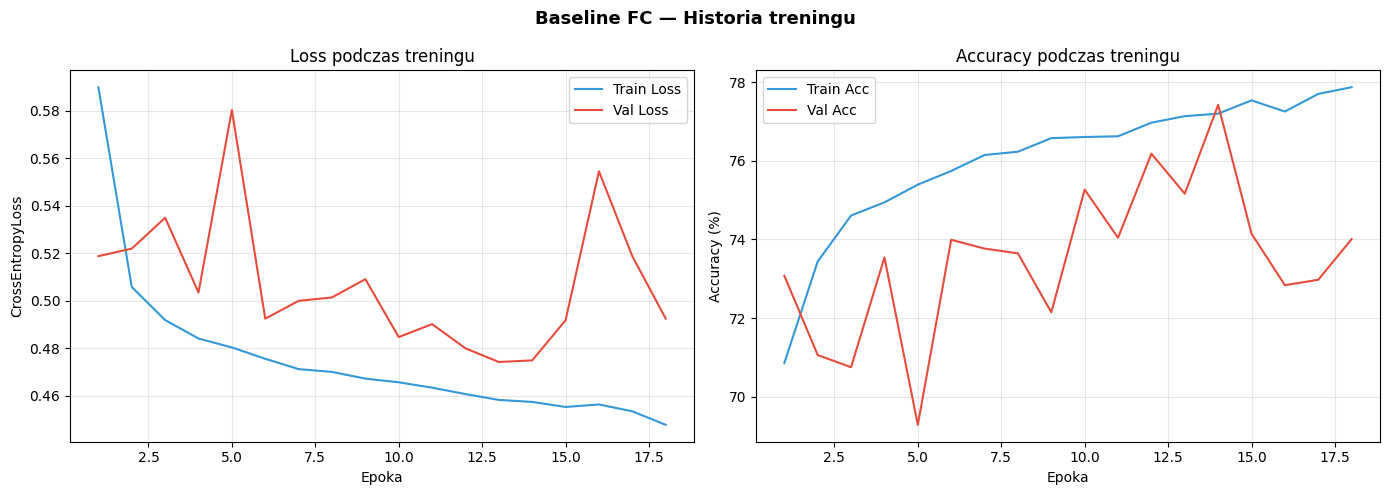

Końcowa val_acc: 74.01%


In [7]:
# Wykres historii treningu
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs, history["train_loss"], label="Train Loss", color="#3498db")
ax1.plot(epochs, history["val_loss"],   label="Val Loss",   color="#e74c3c")
ax1.set_title("Loss podczas treningu")
ax1.set_xlabel("Epoka")
ax1.set_ylabel("CrossEntropyLoss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history["train_acc"], label="Train Acc", color="#3498db")
ax2.plot(epochs, history["val_acc"],   label="Val Acc",   color="#e74c3c")
ax2.set_title("Accuracy podczas treningu")
ax2.set_xlabel("Epoka")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Baseline FC — Historia treningu", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/plots/05_baseline_training.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Końcowa val_acc: {history['val_acc'][-1]:.2f}%")

## 4. Ewaluacja na zbiorze testowym

Zbiór testowy **nie był widziany podczas treningu** — to uczciwa miara skuteczności.

In [8]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = model(X)
        preds = logits.argmax(1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(y.numpy().tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = 100 * accuracy_score(y_true, y_pred)
print(f"=== Test Accuracy: {acc:.3f}% ===\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

=== Test Accuracy: 75.336% ===

              precision    recall  f1-score   support

      Benign     0.9995    1.0000    0.9997      5846
     Spyware     0.4209    0.6789    0.5197      1906
  Ransomware     0.5751    0.5074    0.5391      1963
      Trojan     0.6395    0.3226    0.4289      1897

    accuracy                         0.7534     11612
   macro avg     0.6587    0.6272    0.6219     11612
weighted avg     0.7740    0.7534    0.7498     11612



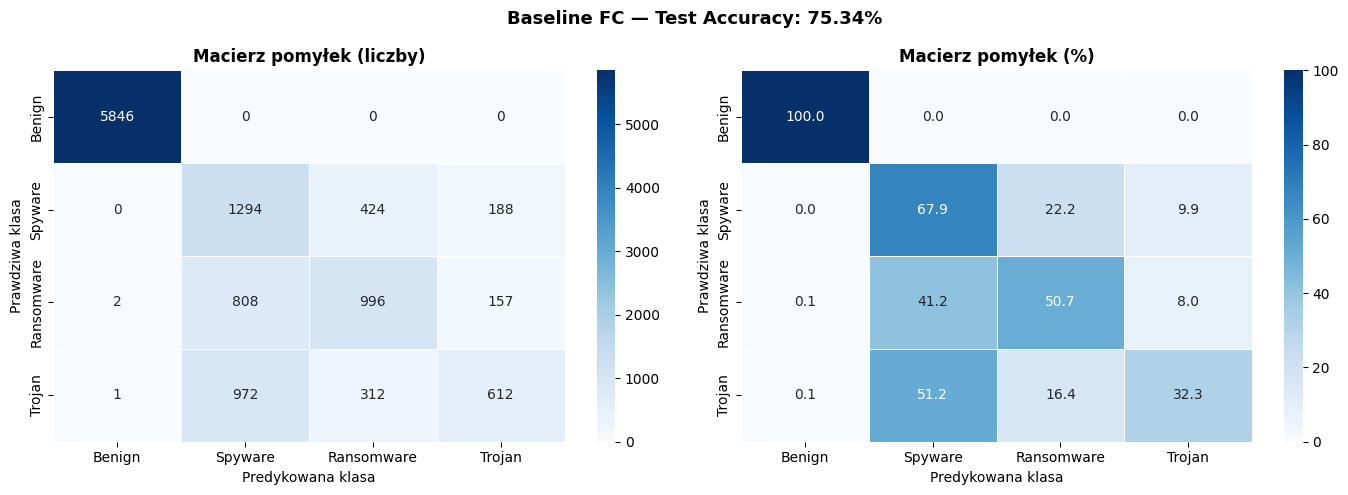

In [9]:
# Macierz pomyłek
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wartości bezwzględne
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0],
            linewidths=0.5)
axes[0].set_title("Macierz pomyłek (liczby)", fontweight="bold")
axes[0].set_ylabel("Prawdziwa klasa")
axes[0].set_xlabel("Predykowana klasa")

# Wartości procentowe
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1],
            linewidths=0.5, vmin=0, vmax=100)
axes[1].set_title("Macierz pomyłek (%)", fontweight="bold")
axes[1].set_ylabel("Prawdziwa klasa")
axes[1].set_xlabel("Predykowana klasa")

plt.suptitle(f"Baseline FC — Test Accuracy: {acc:.2f}%", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/plots/06_baseline_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Zapis wyników i porównanie z artykułem

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pathlib, json

precision = 100 * precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall    = 100 * recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1        = 100 * f1_score(y_true, y_pred, average="weighted", zero_division=0)

results = {
    "model": "FC Baseline (supervised)",
    "accuracy": round(acc, 4),
    "precision_weighted": round(precision, 4),
    "recall_weighted": round(recall, 4),
    "f1_weighted": round(f1, 4),
    "epochs_trained": len(history["train_loss"]),
}

# Zapis do pliku
metrics_path = pathlib.Path(RESULTS_METRICS_DIR) / "baseline_results.json"
metrics_path.parent.mkdir(parents=True, exist_ok=True)
metrics_path.write_text(json.dumps(results, indent=2))
print(f"Zapisano: {metrics_path}")

# Porównanie z artykułem
paper_acc = 99.987
print()
print("=" * 55)
print("  PORÓWNANIE Z ARTYKUŁEM BAZOWYM")
print("=" * 55)
print(f"  Artykuł (EWOA+KNN):  Accuracy = {paper_acc:.3f}%")
print(f"  Nasz FC Baseline:    Accuracy = {acc:.3f}%")
print(f"  Różnica:             {(paper_acc - acc):+.3f} pp")
print()
print(f"  Precision (weighted): {precision:.3f}%")
print(f"  Recall    (weighted): {recall:.3f}%")
print(f"  F1-score  (weighted): {f1:.3f}%")
print("=" * 55)
print()
print("NASTĘPNY KROK → notebooks/03_autoencoder.ipynb")
print("  Autoencoder trenowany BEZ etykiet (anomaly detection)")

Zapisano: C:\Users\Laptop\Desktop\Git\DL-Project\results\metrics\baseline_results.json

  PORÓWNANIE Z ARTYKUŁEM BAZOWYM
  Artykuł (EWOA+KNN):  Accuracy = 99.987%
  Nasz FC Baseline:    Accuracy = 75.336%
  Różnica:             +24.651 pp

  Precision (weighted): 77.397%
  Recall    (weighted): 75.336%
  F1-score  (weighted): 74.981%

NASTĘPNY KROK → notebooks/03_autoencoder.ipynb
  Autoencoder trenowany BEZ etykiet (anomaly detection)
